In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import torch
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import VarianceThreshold
import torch_geometric.transforms as T
from torch_geometric.datasets.dblp import DBLP
import matplotlib.pyplot as plt

## DBLP

In [2]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
author = data['author'].x.tolist()
df = pd.DataFrame(author)
df['class'] = data['author'].y.tolist()

### Feature selection from Bag-of-Words features of Author node using most frequent occurences

In [3]:
def get_selected_features(X):
    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    index_list = []
    for i in sorted_colsum[:8]:
        index_list.append(list(col_sum).index(i))
    imp_feat = X[index_list]
    imp_feat = imp_feat.drop(imp_feat[imp_feat.sum(axis=1) == 0.0].index)

    # col_sum = X.sum(axis=0)
    # sorted_colsum = sorted(col_sum, reverse=True)
    # colsum_df = pd.DataFrame(col_sum)
    
    # sorted_colsum = sorted(col_sum, reverse=True)[:8]
    # index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))
    
    # imp_feat = X[index_list]
    # imp_feat = imp_feat.drop(imp_feat[imp_feat.sum(axis=1) == 0.0].index)


    return imp_feat

In [4]:
# Feature selection for Author class 0
class0 = df[df['class'] == 0].drop(['class'], axis=1)
X = class0
imp_feat0 = get_selected_features(class0)
imp_feat0.head()

,63,64,295,222,65,221,23,296
15,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
30,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
33,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [5]:
# Feature selection for Author class 1
class1 = df[df['class'] == 1].drop(['class'], axis=1)
X = class1
imp_feat1 = get_selected_features(class1)
imp_feat1.head()

,63,170,321,23,39,152,88,35
13,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
23,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
24,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
25,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
27,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
# Feature selection for Author class 2
class2 = df[df['class'] == 2].drop(['class'], axis=1)
X = class2
imp_feat2 = get_selected_features(class2)
imp_feat2.head()

,152,23,321,148,228,295,15,15
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
7,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
8,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0


In [7]:
# Feature selection for Author class 3
class3 = df[df['class'] == 3].drop(['class'], axis=1)
X = class3
imp_feat3 = get_selected_features(class3)
imp_feat3.head()

,242,135,23,321,253,329,302,222
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
20,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
21,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
35,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Features of each class of Author node sampled using Diffusion Models

In [8]:
sampled0  = pd.DataFrame(torch.load('../sampled_features/dblp/features0_new.pt')[0].cpu().numpy())
sampled0.head()

,0,1,2,3,4,5,6,7
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [9]:
sampled1  = pd.DataFrame(torch.load('../sampled_features/dblp/features1_new.pt')[0].cpu().numpy())
sampled1.head()

,0,1,2,3,4,5,6,7
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [10]:
sampled2  = pd.DataFrame(torch.load('../sampled_features/dblp/features2_new.pt')[0].cpu().numpy())
sampled2.head()

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [11]:
sampled3  = pd.DataFrame(torch.load('../sampled_features/dblp/features3_new.pt')[0].cpu().numpy())
sampled3.head()

,0,1,2,3,4,5,6,7
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [12]:
def cosine_sim(original,sampled):
    return cosine_similarity(original, sampled)

### Pairwise cosine similarity of all features for real and synthetic distributions

Author class 0

In [13]:
real_class0= np.array(imp_feat0)
cosine_sim(real_class0,sampled0)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.5       , ..., 0.5       , 0.5       ,
        0.        ],
       [0.        , 0.35355339, 0.5       , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.5       , ..., 0.5       , 0.5       ,
        0.        ],
       [0.        , 0.5       , 0.        , ..., 0.70710678, 0.70710678,
        0.        ]])

In [14]:
sns.set(font_scale=1.4)

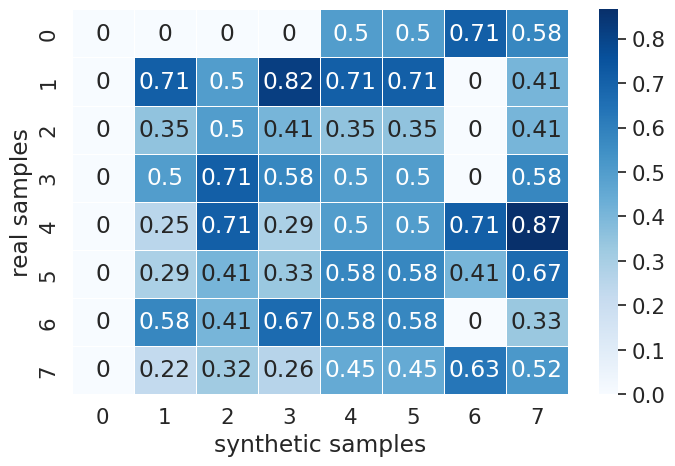

In [15]:
fig, ax = plt.subplots(figsize=(8,5)) 
sns.heatmap(cosine_sim(real_class0[:8],sampled0[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [16]:
avg_cossim_class0 = np.mean(cosine_sim(real_class0,sampled0))
avg_cossim_class0

0.3607023871689565

Author class 1

In [17]:
real_class1= np.array(imp_feat1)
cosine_sim(real_class1,sampled1)

array([[0.66666667, 0.81649658, 0.81649658, ..., 0.81649658, 0.57735027,
        0.81649658],
       [0.66666667, 0.40824829, 0.40824829, ..., 0.40824829, 0.57735027,
        0.40824829],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.40824829, 0.5       , 0.5       , ..., 0.5       , 0.70710678,
        0.5       ],
       [0.57735027, 0.70710678, 0.70710678, ..., 0.70710678, 1.        ,
        0.70710678]])

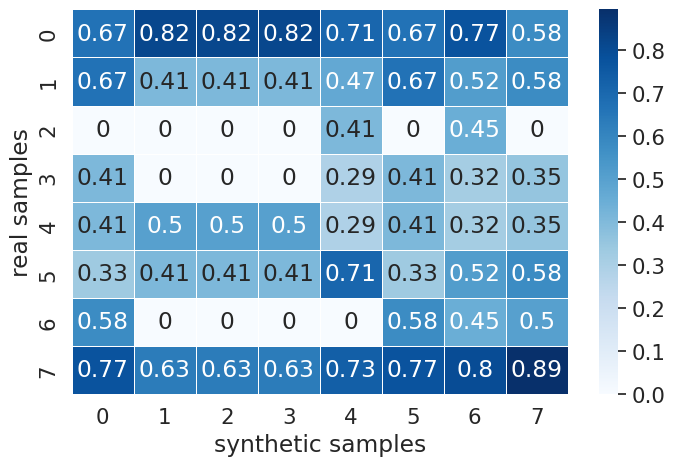

In [18]:
fig, ax = plt.subplots(figsize=(8,5)) 
sns.heatmap(cosine_sim(real_class1[:8],sampled1[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [19]:
avg_cossim_class1 = np.mean(cosine_sim(real_class1,sampled1))
avg_cossim_class1

0.48495392697364265

Author class 2

In [20]:
real_class2= np.array(imp_feat2)
cosine_sim(real_class2,sampled2)

array([[0.        , 0.5       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.5       , ..., 0.        , 0.5       ,
        0.35355339],
       [0.        , 0.8660254 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.5       , 1.        , ..., 0.        , 1.        ,
        0.70710678],
       [0.        , 0.5       , 1.        , ..., 0.        , 1.        ,
        0.70710678],
       [0.        , 0.5       , 0.        , ..., 0.        , 0.        ,
        0.        ]])

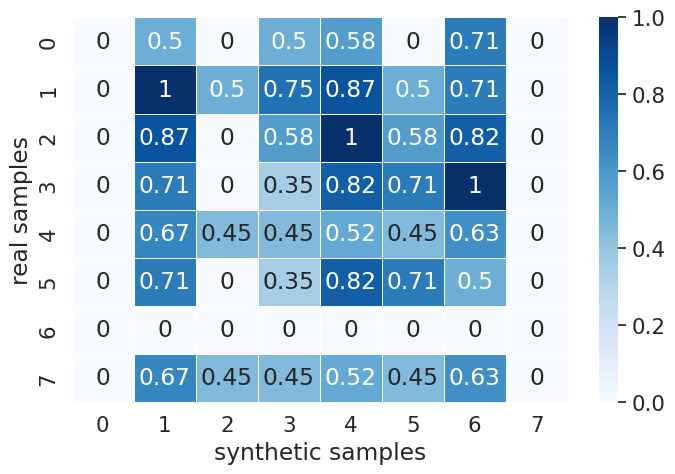

In [21]:
fig, ax = plt.subplots(figsize=(8,5)) 
sns.heatmap(cosine_sim(real_class2[:8],sampled2[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [22]:
avg_cossim_class2 = np.mean(cosine_sim(real_class2,sampled2))
avg_cossim_class2

0.3070055733074983

Author class 3

In [23]:
real_class3 = np.array(imp_feat3)
cosine_sim(real_class3,sampled3)

array([[0.        , 0.70710678, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.40824829,
        0.57735027],
       [0.57735027, 0.40824829, 0.40824829, ..., 0.57735027, 0.81649658,
        0.28867513],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.5       ,
        0.35355339],
       [0.        , 0.        , 0.        , ..., 0.        , 0.5       ,
        0.35355339],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.5       ]])

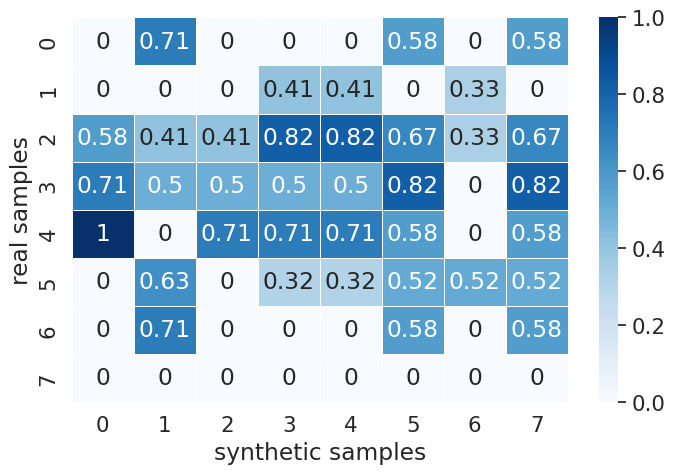

In [24]:
fig, ax = plt.subplots(figsize=(8,5)) 
sns.heatmap(cosine_sim(real_class3[:8],sampled3[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [25]:
avg_cossim_class3 = np.mean(cosine_sim(real_class3,sampled3))
avg_cossim_class3

0.3358884102756254

In [26]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2 + avg_cossim_class3)/4

0.3721375744314307